In [4]:
# lets import the requirements
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [5]:
# lets import the data
df = pd.read_csv("processed_data.csv")
df.head()

,Unnamed: 0,clean_text,status,statement_length,num_words,vocabulary_size,avg_word_length
0,0,oh gosh,3,1.945910,0.693147,0.693147,1.386294
1,1,trouble sleeping confused mind restless heart ...,3,3.912023,1.945910,1.945910,1.945910
2,2,wrong back dear forward doubt stay restless re...,3,4.060443,2.197225,2.079442,1.791759
3,3,shifted focus something else still worried,3,3.737670,1.791759,1.791759,1.945910
4,4,restless restless month boy mean,3,3.465736,1.609438,1.386294,1.791759


In [6]:
# lets drop the columns
df.drop(columns = "Unnamed: 0",inplace = True)

In [7]:
# here we work with support vector machine

In [8]:
# lets make a split of data 
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest = train_test_split(df.drop(columns="status"),df["status"],test_size=0.2,stratify=df["status"],random_state=1)


In [9]:
print(xtrain.shape)

(42036, 5)


In [10]:
# here we use the tfidf for text encoding as this outperforms the bag of words
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

from sklearn.feature_extraction.text import TfidfVectorizer

num_cols = ["statement_length", "num_words", "vocabulary_size", "avg_word_length"]

preprocessor = ColumnTransformer([
    ("text", TfidfVectorizer(max_features=15000), "clean_text"),   # preprocessed text
    ("num", StandardScaler(), num_cols)             # numeric features
])


In [25]:
# lets make a pipeline
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
pipeline_svc = Pipeline([
    ("preprocess", preprocessor),
    ("model", LinearSVC(class_weight="balanced",max_iter=5000,dual="auto"))
])



In [26]:
# lets make the parameter grid

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform

param_dist = {
    "model__C": uniform(0.1, 10)
}



In [27]:

# RandomizedSearchCV
random_search_svc = RandomizedSearchCV(
    pipeline_svc,
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    scoring="f1_macro",   # important
    n_jobs=-1,
    verbose=2,
    random_state=42
)



In [28]:
# lets fit it on our data
random_search_svc.fit(xtrain, ytrain)



Fitting 3 folds for each of 20 candidates, totalling 60 fits


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocess',
                                              ColumnTransformer(transformers=[('text',
                                                                               TfidfVectorizer(max_features=15000),
                                                                               'clean_text'),
                                                                              ('num',
                                                                               StandardScaler(),
                                                                               ['statement_length',
                                                                                'num_words',
                                                                                'vocabulary_size',
                                                                                'avg_word_length'])])),
                                             ('model',
                                              LinearSVC(class_weight='balanced',
                                                        dual='auto',
                                                        max_iter=5000))]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'model__C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x0000029902200590>},
                   random_state=42, scoring='f1_macro', verbose=2)

In [30]:
# lets check the best parameters
best_svc = random_search_svc.best_estimator_

print("Best Params:", random_search_svc.best_params_)
print("Best Score:", random_search_svc.best_score_)

Best Params: {'model__C': 0.30584494295802445}
Best Score: 0.7079522161787285


              precision    recall  f1-score   support

           0       0.89      0.93      0.91      3243
           1       0.77      0.64      0.70      3081
           2       0.67      0.69      0.68      2129
           3       0.77      0.84      0.80       768
           4       0.77      0.82      0.80       555
           5       0.53      0.64      0.58       518
           6       0.56      0.77      0.65       215

    accuracy                           0.77     10509
   macro avg       0.71      0.76      0.73     10509
weighted avg       0.77      0.77      0.77     10509



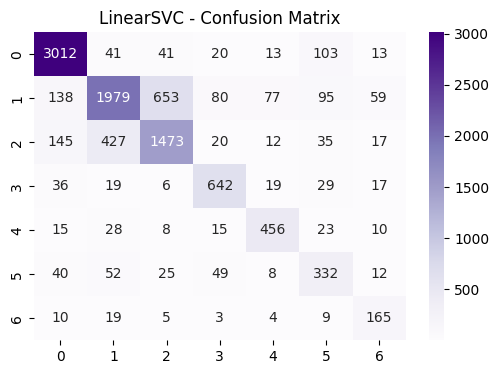

In [31]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = best_svc.predict(xtest)

print(classification_report(ytest, y_pred))

cm = confusion_matrix(ytest, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Purples")
plt.title("LinearSVC - Confusion Matrix")
plt.show()

## Model Comparison: Tuned Logistic Regression vs Tuned Linear SVC

### 1. Overall Performance

| Metric            | Logistic Regression | Linear SVC |
|------------------|--------------------|------------|
| Accuracy         | 0.76               | **0.77** |
| Macro F1-score   | 0.73               | 0.73 |
| Weighted F1-score| 0.76               | **0.77** |

**Observation:**  
Linear SVC shows a marginal improvement in overall accuracy and weighted F1, while maintaining the same macro F1-score.

---

### 2. Class-wise Performance

| Class | Precision (LR) | Recall (LR) | F1 (LR) | Precision (SVC) | Recall (SVC) | F1 (SVC) |
|------|----------------|-------------|--------|------------------|-------------|----------|
| 0 | 0.91 | 0.91 | 0.91 | 0.89 | 0.93 | 0.91 |
| 1 | 0.76 | 0.62 | 0.69 | 0.77 | 0.64 | 0.70 |
| 2 | 0.64 | 0.72 | 0.68 | 0.67 | 0.69 | 0.68 |
| 3 | 0.77 | 0.82 | 0.80 | 0.77 | 0.84 | 0.80 |
| 4 | 0.78 | 0.83 | 0.81 | 0.77 | 0.82 | 0.80 |
| 5 | 0.52 | 0.68 | 0.59 | 0.53 | 0.64 | 0.58 |
| 6 | 0.62 | 0.76 | 0.68 | 0.56 | 0.77 | 0.65 |

---

### 3. Key Differences

- **Accuracy Improvement:**  
  Linear SVC improves accuracy from **0.76 → 0.77**, indicating better generalization.

- **Minority Class Recall:**  
  - Class 6 recall improves slightly (**0.76 → 0.77**)  
  - Class 5 recall slightly decreases (**0.68 → 0.64**)  
  Overall, both models handle minority classes reasonably well, with SVC maintaining strong recall.

- **Precision Trade-off:**  
  - Slight drop in precision for minority classes (e.g., Class 6: 0.62 → 0.56)  
  - Indicates SVC is more **recall-oriented**, accepting more false positives.

---

### 4. Trade-off Analysis

| Aspect | Logistic Regression | Linear SVC |
|--------|--------------------|------------|
| Precision | Slightly higher | Slightly lower |
| Recall | Balanced | Slightly higher |
| Generalization | Good | **Better** |
| Minority Detection | Strong | **Slightly improved** |

**Interpretation:**  
- Logistic Regression is slightly more **conservative**  
- Linear SVC is slightly more **aggressive**, improving detection at the cost of precision  

---

### 5. Model Behavior

- **Logistic Regression:**
  - Optimizes probability estimates
  - Produces stable and interpretable predictions
  - Slightly favors precision

- **Linear SVC:**
  - Maximizes margin between classes
  - Handles high-dimensional sparse data effectively
  - Improves class separation and generalization

---

### 6. Conclusion

Both models perform strongly with balanced metrics. However:

- **Linear SVC** achieves slightly better accuracy and generalization
- It maintains competitive macro F1 while improving recall for several classes
- The trade-off is a minor reduction in precision

**Final Recommendation:**  
Linear SVC is the preferred model for this task due to its improved generalization and stronger performance on high-dimensional sparse text data.